# Joined (UniProt + ClinVar) EDA

Outer join of the two cleaned parquets on **UniProt primary gene** (first token of `Gene Names`) = **ClinVar gene**.

ClinVar `GeneSymbol` is a `;`-delimited gene list (e.g. `KLLN;LOC130004273;MLDHR;PTEN`), so each variant is **exploded to one row per gene** before joining; the original list is kept in `GeneSymbolFull`.

Built by `python src/join_clinvar_uniprot.py` → `data/processed/clinvar_uniprot_joined.parquet`.

Row grain: one row per (protein, variant-gene) pair for shared genes, plus unmatched proteins (ClinVar columns null) and unmatched variant-genes (UniProt columns null). `match_type` flags each row as `both` / `uniprot_only` / `clinvar_only`.

If the variant sits in a genomic region where multiple genes overlap or are immediately adjacent, and ClinVar's annotation pipeline (using RefSeq/NCBI gene models) has assigned it to all genes whose boundaries the position falls into or near.

In [1]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

In [2]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
JOINED_PARQUET = project_root / "data/processed/clinvar_uniprot_joined.parquet"
UNIPROT_RAW = project_root / "data/raw/uniprot_human_reviewed.parquet"
UNIPROT_CLEAN = project_root / "data/processed/uniprot_clean.parquet"
JOINED_VUS = project_root / "data/processed/clinvar_uniprot_joined_vus.parquet"


In [3]:
# %run "{project_root}/src/ingest_clinvar.py"
# %run "{project_root}/src/ingest_uniprot.py"

In [4]:
# import sys
# sys.path.append(str(project_root / "src"))
# import ingest_clinvar, ingest_uniprot
# import clean_clinvar, clean_uniprot, join_clinvar_uniprot
# clean_clinvar.main()
# clean_uniprot.main()
# join_clinvar_uniprot.main()

In [5]:
df = pd.read_parquet(JOINED_PARQUET)
df.shape


(16863, 42)

In [6]:
df.head(2)

,join_id,Entry,Entry Name,Gene Names,Protein names,Length,Function [CC],Involvement in disease,Subcellular location [CC],Interacts with,...,Stop,ReviewStatus,NumberSubmitters,VariationID,ReferenceAlleleVCF,AlternateAlleleVCF,label,GeneSymbolFull,match_type,gene
0,0,A8K2U0,A2ML1_HUMAN,A2ML1 CPAMD9,Alpha-2-macroglobulin-like protein 1 (C3 and P...,1454.0,Is able to inhibit all four classes of protein...,Otitis media (OM) [MIM:166760]: An inflammatio...,SUBCELLULAR LOCATION: Secreted {ECO:0000269|Pu...,None,...,<NA>,None,<NA>,NaN,<NA>,<NA>,None,<NA>,uniprot_only,A2ML1
1,1,Q9NRG9,AAAS_HUMAN,AAAS ADRACALA GL003,Aladin (Adracalin),546.0,Plays a role in the normal development of the ...,Achalasia-addisonianism-alacrima syndrome (AAA...,"SUBCELLULAR LOCATION: Nucleus, nuclear pore co...",None,...,<NA>,None,<NA>,NaN,<NA>,<NA>,None,<NA>,uniprot_only,AAAS


## Why UniProt is filtered to `Involvement in disease`

`clean_uniprot.py` already applies this before the join: keep only Swiss-Prot human proteins with a disease comment (`DISEASE: …` / OMIM). That is **not** “other proteins cannot cause disease”; it is “UniProt curators wrote a disease blurb.”

The ClinVar table here is expert-reviewed Mendelian variants, not the whole proteome. Without the filter the outer join would add thousands of `uniprot_only` proteins that never appear in training.

The cell below checks that the joined table is the filtered set (every protein-side row has a disease comment).


In [7]:
raw_u = pd.read_parquet(UNIPROT_RAW)
clean_u = pd.read_parquet(UNIPROT_CLEAN)

n_raw = len(raw_u)
n_disease = int(raw_u["Involvement in disease"].notna().sum())
print(f"Swiss-Prot human reviewed: {n_raw:,}")
print(f"  with Involvement in disease: {n_disease:,} ({n_disease / n_raw:.0%})")
print(f"  kept in uniprot_clean (join input): {len(clean_u):,}")

uniprot_side = df[df["Entry"].notna()]
n_missing = int(uniprot_side["Involvement in disease"].isna().sum())
print()
print("Applied on this joined table?")
print(f"  protein-side rows: {len(uniprot_side):,}")
print(f"  missing Involvement in disease: {n_missing}  (must be 0)")
print(f"  distinct proteins: {uniprot_side['Entry'].nunique():,}")
assert n_missing == 0
assert uniprot_side["Entry"].nunique() == len(clean_u)

labelled = df[df["label"].isin(["pathogenic", "benign"])]
print()
print("Joined labelled rows by match_type:")
print(labelled["match_type"].value_counts().to_string())
n_unmatched = labelled.loc[labelled["match_type"] == "clinvar_only", "VariationID"].nunique()
n_matched = labelled.loc[labelled["match_type"] == "both", "VariationID"].nunique()
print()
print(
    f"Labelled VariationIDs unmatched to UniProt: {n_unmatched} / {n_unmatched + n_matched}"
    f"  (mostly MT-tRNA / LOC / MIR, not typical Swiss-Prot disease entries)"
)


Swiss-Prot human reviewed: 20,431
  with Involvement in disease: 5,330 (26%)
  kept in uniprot_clean (join input): 5,330

Applied on this joined table?
  protein-side rows: 16,774
  missing Involvement in disease: 0  (must be 0)
  distinct proteins: 5,330

Joined labelled rows by match_type:
match_type
both            11586
clinvar_only       89

Labelled VariationIDs unmatched to UniProt: 86 / 11649  (mostly MT-tRNA / LOC / MIR, not typical Swiss-Prot disease entries)


## Join impact: where do the rows come from?

`both` = (protein, variant) pairs on shared genes · `uniprot_only` = proteins with no expert-reviewed variant · `clinvar_only` = variants whose gene has no disease-annotated reviewed protein.

In [8]:
df["match_type"].value_counts(dropna=False)

match_type
both            11586
uniprot_only     5188
clinvar_only       89
Name: count, dtype: int64

In [9]:
# Input rows vs join output, and how many source records actually matched
n_uniprot = df["Entry"].notna().sum()
n_clinvar = df["VariationID"].notna().sum()
uniprot_genes = set(df.loc[df["Entry"].notna(), "gene"].dropna())
clinvar_genes = set(df.loc[df["VariationID"].notna(), "gene"].dropna())

pd.DataFrame({
    "metric": [
        "joined rows (total)",
        "rows carrying a UniProt protein",
        "rows carrying a ClinVar variant",
        "unique genes (any source)",
        "genes in BOTH sources",
        "genes UniProt-only",
        "genes ClinVar-only",
        "distinct proteins kept (Entry)",
        "distinct variants kept (VariationID)",
    ],
    "value": [
        len(df),
        int(n_uniprot),
        int(n_clinvar),
        df["gene"].nunique(),
        len(uniprot_genes & clinvar_genes),
        len(uniprot_genes - clinvar_genes),
        len(clinvar_genes - uniprot_genes),
        df["Entry"].nunique(),
        df["VariationID"].nunique(),
    ],
})

,metric,value
0,joined rows (total),16863
1,rows carrying a UniProt protein,16774
2,rows carrying a ClinVar variant,11675
3,unique genes (any source),5356
4,genes in BOTH sources,142
5,genes UniProt-only,5183
6,genes ClinVar-only,31
7,distinct proteins kept (Entry),5330
8,distinct variants kept (VariationID),11635


## Fan-out: variants per gene (why `both` is so large)

The outer join multiplies each protein by every variant on its gene, so a few high-variant genes dominate the row count.

In [10]:
# Top genes by number of distinct ClinVar variants (matched genes only)
both = df[df["match_type"] == "both"]
both.groupby("gene")["VariationID"].nunique().sort_values(ascending=False).head(15)

gene
BRCA2     2020
BRCA1     1569
RUNX1      660
PAH        515
MLH1       347
GCK        327
MSH2       296
CFTR       238
LDLR       229
GAA        223
CDH1       207
HNF1A      201
ITGA2B     187
DYSF       176
PTEN       155
Name: VariationID, dtype: int64

In [11]:
# Genes with more than one reviewed protein (these also multiply the rows)
multi_protein = (
    df[df["Entry"].notna()].groupby("gene")["Entry"].nunique()
)
multi_protein[multi_protein > 1].sort_values(ascending=False)

gene
GNAS     4
ERCC6    2
MOCS2    2
Name: Entry, dtype: int64

In [12]:
g = 'MOCS2'
df[df['gene'] == g]



,join_id,Entry,Entry Name,Gene Names,Protein names,Length,Function [CC],Involvement in disease,Subcellular location [CC],Interacts with,...,Stop,ReviewStatus,NumberSubmitters,VariationID,ReferenceAlleleVCF,AlternateAlleleVCF,label,GeneSymbolFull,match_type,gene
10796,10796,O96007,MOC2B_HUMAN,MOCS2 MCBPE MOCO1,Molybdopterin synthase catalytic subunit (EC 2...,188.0,Catalytic subunit of the molybdopterin synthas...,"Molybdenum cofactor deficiency, type B1 (MOCOD...","SUBCELLULAR LOCATION: Cytoplasm, cytosol {ECO:...",O96033,...,<NA>,None,<NA>,NaN,<NA>,<NA>,None,<NA>,uniprot_only,MOCS2
10797,10797,O96033,MOC2A_HUMAN,MOCS2 MOCO1,Molybdopterin synthase sulfur carrier subunit ...,88.0,Acts as a sulfur carrier required for molybdop...,"Molybdenum cofactor deficiency, type B1 (MOCOD...","SUBCELLULAR LOCATION: Cytoplasm, cytosol {ECO:...",O96007,...,<NA>,None,<NA>,NaN,<NA>,<NA>,None,<NA>,uniprot_only,MOCS2


GNAS is a textbook case of a genuinely complex locus: it produces multiple distinct protein products from the same genomic region through alternative promoters and alternative splicing, and it's an imprinted gene (parent-of-origin-specific expression).

ERCC6 CSB is a historical name for ERCC6, stands for the primary disorder linked to its mutation, Cockayne Syndrome B (CS-B).

MOCS2 MCBPE MOCO1 is also an alias for the MOCS2 MOCO1, stands for Molybdenum Cofactor Biosynthesis Protein E.

## What the join adds vs. drops

`clinvar_only` genes = reviewed variants we could **not** attach to a disease-annotated UniProt protein (lost protein context). `uniprot_only` genes = disease proteins with no expert-reviewed variant in the cleaned ClinVar set.

In [13]:
# ClinVar-only genes (variants with no matched protein) and their variant counts
clinvar_only = df[df["match_type"] == "clinvar_only"]
print("clinvar_only genes:", clinvar_only["gene"].nunique())
clinvar_only.groupby("gene")["VariationID"].nunique().sort_values(ascending=False)

clinvar_only genes: 31


gene
MT-TL1                                                               13
RMRP                                                                 13
HBA2                                                                  9
MT-TS1                                                                8
MT-TK                                                                 5
LOC130004273                                                          4
MT-TN                                                                 3
MT-TL2                                                                3
MT-TS2                                                                2
MT-TW                                                                 2
DVL2                                                                  2
MIR6886                                                               2
MT-TH                                                                 2
MT-TF                                                      

In [14]:
# Clinical significance of the variants that now carry protein context (match_type == both)
both["ClinicalSignificance"].value_counts(dropna=False)

ClinicalSignificance
Pathogenic                      4085
Likely benign                   2710
Benign                          2516
Likely pathogenic               2271
Pathogenic/Likely pathogenic       3
Benign/Likely benign               1
Name: count, dtype: int64

## One joined record: protein context + a clinical variant side by side

In [15]:
cols = [
    "gene", "match_type",
    "Entry", "Entry Name", "Protein names", "Involvement in disease",
    "VariationID", "Name", "ClinicalSignificance", "PhenotypeList",
]
df[df["gene"] == "BRCA1"][cols].head(5)

,gene,match_type,Entry,Entry Name,Protein names,Involvement in disease,VariationID,Name,ClinicalSignificance,PhenotypeList
1083,BRCA1,both,P38398,BRCA1_HUMAN,Breast cancer type 1 susceptibility protein (E...,Breast cancer (BC) [MIM:114480]: A common mali...,17661.0,NM_007294.4(BRCA1):c.181T>G (p.Cys61Gly),Pathogenic,"Breast-ovarian cancer, familial, susceptibilit..."
1084,BRCA1,both,P38398,BRCA1_HUMAN,Breast cancer type 1 susceptibility protein (E...,Breast cancer (BC) [MIM:114480]: A common mali...,17670.0,NM_007294.4(BRCA1):c.3119G>A (p.Ser1040Asn),Benign,"Breast-ovarian cancer, familial, susceptibilit..."
1085,BRCA1,both,P38398,BRCA1_HUMAN,Breast cancer type 1 susceptibility protein (E...,Breast cancer (BC) [MIM:114480]: A common mali...,17671.0,NM_007294.4(BRCA1):c.3607C>T (p.Arg1203Ter),Pathogenic,"Breast-ovarian cancer, familial, susceptibilit..."
1086,BRCA1,both,P38398,BRCA1_HUMAN,Breast cancer type 1 susceptibility protein (E...,Breast cancer (BC) [MIM:114480]: A common mali...,17672.0,NM_007294.4(BRCA1):c.3748G>T (p.Glu1250Ter),Pathogenic,"Breast-ovarian cancer, familial, susceptibilit..."
1087,BRCA1,both,P38398,BRCA1_HUMAN,Breast cancer type 1 susceptibility protein (E...,Breast cancer (BC) [MIM:114480]: A common mali...,17675.0,NM_007294.4(BRCA1):c.4327C>T (p.Arg1443Ter),Pathogenic,"Breast-ovarian cancer, familial, susceptibilit..."


What's still unmatched (the remaining 31 clinvar_only genes)
These are genuinely outside the disease-filtered UniProt set, so they should stay unmatched:

- Mitochondrial tRNA genes: MT-TL1 (13), MT-TS1 (8), MT-TK (5), MT-TN, MT-TL2, … (not protein-coding)
- Non-coding RNAs: RMRP (13), MIR6886 (2)
- Uncharacterized loci / others: LOC130004273, LOC106804612
- Others: MLDHR, MKRN2, DVL2, HBA1/HBA2

In [16]:
g = 'MLDHR'
df[df['gene'] == g].iloc[:,19:].values[0]

array([None, 'single nucleotide variant', 'NM_000314.6(PTEN):c.-903G>A',
       'MLDHR', '-', 'Benign', 'Sep 14, 2016',
       'MedGen:CN169374|MedGen:C3661900|MONDO:MONDO:0017623,MeSH:D006223,MedGen:C1959582,Orphanet:306498|MONDO:MONDO:0015356,MeSH:D009386,MedGen:C0027672,Orphanet:140162',
       'PTEN hamartoma tumor syndrome. Hereditary cancer-predisposing syndrome',
       'germline', 'GRCh38', '10', 87863566, 87863566,
       'reviewed by expert panel', 7, 138837.0, 'G', 'A', 'benign',
       'KLLN;LOC130004273;MLDHR;PTEN', 'clinvar_only', 'MLDHR'],
      dtype=object)

## Charts: match_type and gene fan-out

`both` is large because mega-genes (BRCA1/2, TTN, …) contribute hundreds of variants, not because the join is Cartesian by accident.


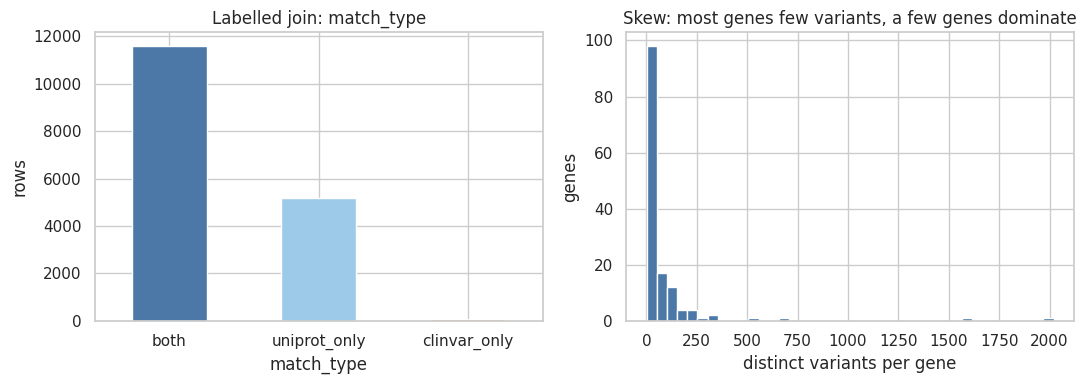

gene
BRCA2    2020
BRCA1    1569
RUNX1     660
PAH       515
MLH1      347
GCK       327
MSH2      296
CFTR      238


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["match_type"].value_counts().plot(
    kind="bar", ax=axes[0], rot=0, color=["#4c78a8", "#9ecae9", "#f58518"],
)
axes[0].set_ylabel("rows")
axes[0].set_title("Labelled join: match_type")

per_gene = (
    df.loc[df.match_type == "both"]
    .groupby("gene")["VariationID"].nunique()
    .sort_values(ascending=False)
)
axes[1].hist(per_gene, bins=40, color="#4c78a8")
axes[1].set_xlabel("distinct variants per gene")
axes[1].set_ylabel("genes")
axes[1].set_title("Skew: most genes few variants, a few genes dominate")
plt.tight_layout()
plt.show()
print(per_gene.head(8).to_string())


## VUS join (left / ClinVar-centric)

`join_clinvar_uniprot.py --vus` keeps every VUS gene even when UniProt has no disease protein (`clinvar_only`). Compare match rates to the labelled outer join.


VUS join (3615, 42)
match_type
both            3512
clinvar_only     103

labelled P/B    unique variants 11635  matched to UniProt 11563 (99.4%)
VUS             unique variants  3606  matched to UniProt  3506 (97.2%)


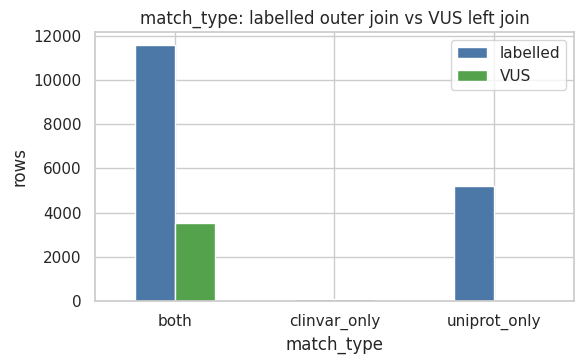

In [18]:
vus = pd.read_parquet(JOINED_VUS)
print("VUS join", vus.shape)
print(vus["match_type"].value_counts().to_string())
print()
for name, frame in [("labelled P/B", df), ("VUS", vus)]:
    has = frame["VariationID"].notna()
    both = frame["match_type"].eq("both")
    n_var = frame.loc[has, "VariationID"].nunique()
    n_both = frame.loc[both, "VariationID"].nunique()
    print(f"{name:14s}  unique variants {n_var:5d}  matched to UniProt {n_both:5d} ({n_both / n_var:.1%})")

fig, ax = plt.subplots(figsize=(6, 3.8))
cmp = pd.DataFrame({
    "labelled": df["match_type"].value_counts(),
    "VUS": vus["match_type"].value_counts(),
}).fillna(0)
cmp.plot(kind="bar", ax=ax, rot=0, color=["#4c78a8", "#54a24b"])
ax.set_ylabel("rows")
ax.set_title("match_type: labelled outer join vs VUS left join")
plt.tight_layout()
plt.show()
